In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.interpolate import CubicSpline
import matplotlib.colors as mcolors
import cmasher as cmr

from generate_colormap import *


from functools import partial
import starsim

from astropy.io import fits

from scipy.optimize import curve_fit

In [2]:
mu_ph = fits.open('/home/sophie-stucki/starsim/starsim/models/Phoenix_mu/lte05800-4.50-0.0.PHOENIX-ACES-AGSS-COND-SPECINT-2011.fits')[1].data
data_ph = fits.open('/home/sophie-stucki/starsim/starsim/models/Phoenix_mu/lte05800-4.50-0.0.PHOENIX-ACES-AGSS-COND-SPECINT-2011.fits')[0].data

mu_mps = np.linspace(0.1, 1.0, 10)
data_mps = np.load('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/MPS-ATLAS_spectra/av_solar_ssd_10_mu_angles_cleaned.npy', allow_pickle=True).item()


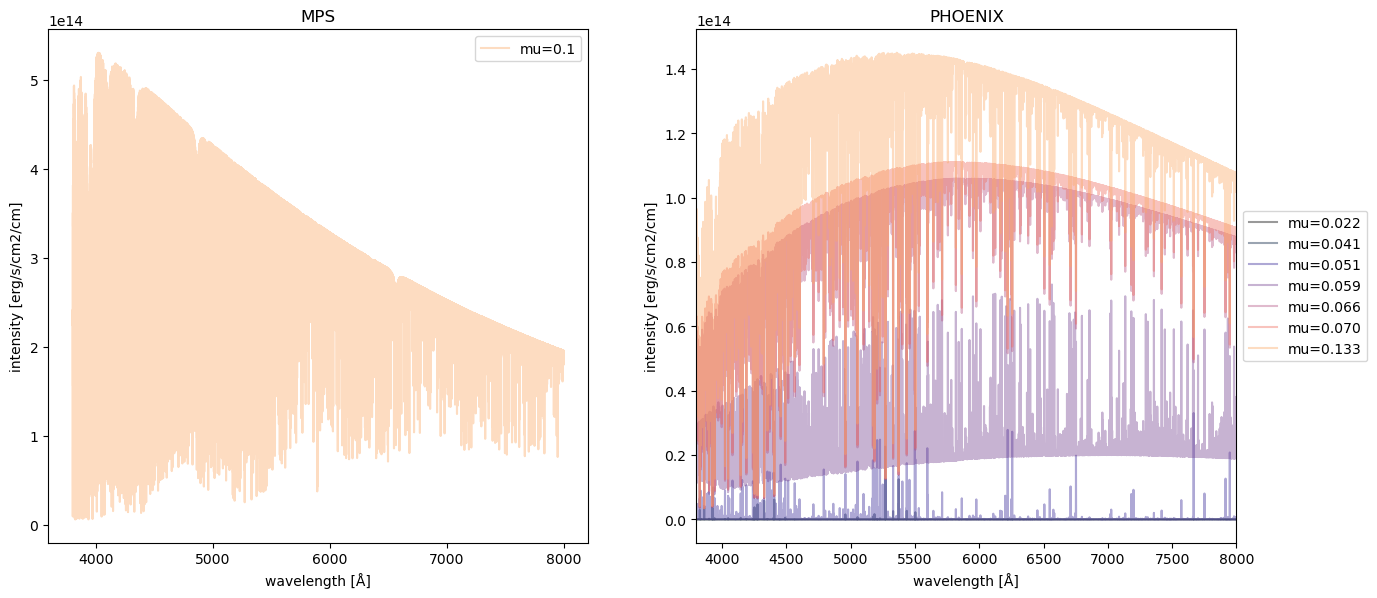

In [3]:
N=7

mu_ph_chosen = np.array([0.021601, 0.040637, 0.051179, 0.0588, 0.066016, 0.070037, 0.13276])

colors = cmr.take_cmap_colors('cmr.torch', N,cmap_range=(0, 0.8), return_fmt='hex')

fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(20/1.5 + 2, 10/1.5))

for i, amu in enumerate(mu_ph_chosen):

    if amu > mu_mps.min():
        mu_low=np.max(mu_ph[mu_ph<amu]) #angles above and below the proj. angle of the grid
        mu_upp=np.min(mu_ph[mu_ph>=amu])
        idx_low=np.where(mu_ph==mu_low)[0][0]
        idx_upp=np.where(mu_ph==mu_upp)[0][0]
        
        # dlp_mps = data_mps['{:.1f}'.format(mu_low)]['intensity']+(data_mps['{:.1f}'.format(mu_upp)]['intensity']-data_mps['{:.1f}'.format(mu_low)]['intensity'])*(amu-mu_low)/(mu_upp-mu_low)
        dlp_ph = data_ph[idx_low]+(data_ph[idx_upp]-data_ph[idx_low])*(amu-mu_low)/(mu_upp-mu_low)

    elif amu < mu_mps.min() and amu > mu_ph.min():
        mu_low=np.max(mu_ph[mu_ph<amu]) #angles above and below the proj. angle of the grid
        mu_upp=np.min(mu_ph[mu_ph>=amu])
        idx_low=np.where(mu_ph==mu_low)[0][0]
        idx_upp=np.where(mu_ph==mu_upp)[0][0]
        dlp_ph = data_ph[idx_low]+(data_ph[idx_upp]-data_ph[idx_low])*(amu-mu_low)/(mu_upp-mu_low)

        # dlp_mps = amu / mu_mps.min() * data_mps['{:.1f}'.format(mu_mps.min())]['intensity']

    else: 
        mu_upp=np.min(mu_ph[mu_ph>=amu])
        idx_upp=np.where(mu_ph==mu_upp)[0][0]

        dlp_ph = amu / mu_ph.min() * data_ph[idx_upp]
        # dlp_mps = amu / mu_mps.min() * data_mps['{:.1f}'.format(mu_mps.min())]['intensity']


    # dlp_mps = dlp_mps / (1e-8 * data_mps['1.0']['wav'])**2 * 2.99792458e10

    axs[1].plot(np.arange(500,500+len(dlp_ph)),dlp_ph, alpha = 0.4, label='mu={:.3f}'.format(amu),color=colors[i])

axs[0].plot(data_mps['1.0']['wav'], data_mps['1.0']['intensity']/ (1e-8 * data_mps['1.0']['wav'])**2 * 2.99792458e10, alpha = 0.4, label='mu=0.1',color=colors[-1])

axs[1].set_xlim(3800,8000)
axs[0].set_title('MPS')
axs[1].set_title('PHOENIX')
axs[0].set_ylabel('intensity [erg/s/cm2/cm]')
axs[1].set_ylabel('intensity [erg/s/cm2/cm]')
axs[0].set_xlabel('wavelength [Å]')
axs[1].set_xlabel('wavelength [Å]')


axs[0].legend()
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/limb_extrapolation/spectra_mu_old.png', bbox_inches='tight')



    



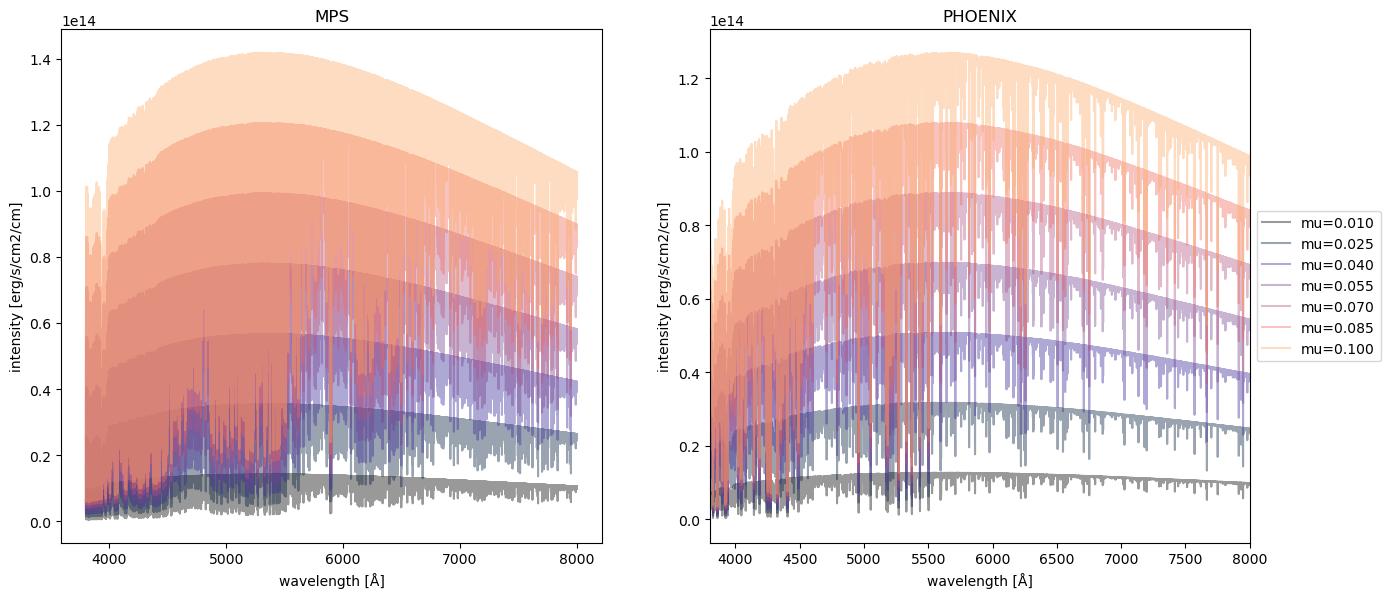

In [4]:

fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(20/1.5 + 2, 10/1.5))

for i,amu in enumerate(np.linspace(0.01,0.1,N)):

    if amu > 0.1:
        mu_low=np.max(mu_ph[mu_ph<amu]) #angles above and below the proj. angle of the grid
        mu_upp=np.min(mu_ph[mu_ph>=amu])
        idx_low=np.where(mu_ph==mu_low)[0][0]
        idx_upp=np.where(mu_ph==mu_upp)[0][0]
        
        dlp_mps = data_mps['{:.1f}'.format(mu_low)]['intensity']+(data_mps['{:.1f}'.format(mu_upp)]['intensity']-data_mps['{:.1f}'.format(mu_low)]['intensity'])*(amu-mu_low)/(mu_upp-mu_low)
        dlp_ph = data_ph[idx_low]+(data_ph[idx_upp]-data_ph[idx_low])*(amu-mu_low)/(mu_upp-mu_low)


    else: 
        mu_low=np.max(mu_ph[mu_ph<0.1]) #angles above and below the proj. angle of the grid
        mu_upp=np.min(mu_ph[mu_ph>=0.1])
        idx_low=np.where(mu_ph==mu_low)[0][0]
        idx_upp=np.where(mu_ph==mu_upp)[0][0]
        dlp_ph_lim = data_ph[idx_low]+(data_ph[idx_upp]-data_ph[idx_low])*(0.1-mu_low)/(mu_upp-mu_low)

        dlp_ph = amu / 0.1 * dlp_ph_lim
        dlp_mps = amu / 0.1 * data_mps['{:.1f}'.format(mu_mps.min())]['intensity']


    dlp_mps = dlp_mps / (1e-8 * data_mps['1.0']['wav'])**2 * 2.99792458e10

    axs[0].plot(data_mps['1.0']['wav'], dlp_mps, alpha = 0.4, label='mu={:.3f}'.format(amu),color=colors[i])
    axs[1].plot(np.arange(500,500+len(dlp_ph)),dlp_ph, alpha = 0.4, label='mu={:.3f}'.format(amu),color=colors[i])

axs[1].set_xlim(3800,8000)
axs[0].set_title('MPS')
axs[1].set_title('PHOENIX')
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axs[0].set_ylabel('intensity [erg/s/cm2/cm]')
axs[1].set_ylabel('intensity [erg/s/cm2/cm]')
axs[0].set_xlabel('wavelength [Å]')
axs[1].set_xlabel('wavelength [Å]')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/limb_extrapolation/spectra_mu_linear_extrapolation.png', bbox_inches='tight')


In [5]:
conf_file_path = "/home/sophie-stucki/starsim/starsim/starsim_sun_limb_test.conf"

In [6]:
def simulation_init(type_list, spot_size_list, latitude_list, longitude_list, conf_file_path, dT_fc=None):
    """
    Iniialization of the starsim simulation for a particular set of parameters

    Params:
            -Q: facular_area_ratio
    Return:
            - ss: starsim object

    """
    
    #create the starsim object
    ss=starsim.StarSim(conf_file_path=conf_file_path)


    #set the Q parameter
    ss.active_region_types=type_list

    if dT_fc !=None:
        ss.facula_T_contrast = dT_fc

    #initialize the spot
    overlap=True

    #TODO: more modulable
    Nspots=len(spot_size_list)
    ss.spot_map=np.zeros([Nspots,8])
    for j in range(Nspots):
        ss.spot_map[j][0]=type_list[j]
        ss.spot_map[j][2]=200#lifetime spot
        ss.spot_map[j][1]=0#appearance time
        ss.spot_map[j][3]=latitude_list[j]#latitude (degrees) [0,180]
        ss.spot_map[j][4]=longitude_list[j]#longitude (degrees)	[0,360]
        ss.spot_map[j][5]=spot_size_list[j]#spot size (degrees)
    return ss

In [7]:
type_list = [1]
spot_size_list = [10]
latitude_list = [90]
longitude_list = [250, 250]

period = 25
periods_nbr = 0.8
point_nbr = 4


t=np.linspace(0,period *periods_nbr,int(period *periods_nbr*point_nbr))

In [8]:
ss_standard = simulation_init(type_list, spot_size_list, latitude_list, longitude_list, conf_file_path)
ss_standard.compute_forward(observables=['lc', 'rv'],t=t)

ss_const = simulation_init(type_list, spot_size_list, latitude_list, longitude_list, conf_file_path)
ss_const.limb_lim = 0.1
ss_const.compute_forward(observables=['lc', 'rv'],t=t)

ss_lin = simulation_init(type_list, spot_size_list, latitude_list, longitude_list, conf_file_path)
ss_lin.limb_lim = 0.1
ss_lin.limb_extrapolation = 'linear'
ss_lin.compute_forward(observables=['lc', 'rv'],t=t)


PHOENIX spectra
Date 20.0. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [80/80]%000%. [79/80]%RV shift
Date 20.0. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [80/80]%PHOENIX spectra
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Date 20.0. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [80/80]%000%. [79/80]%RV shift
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Lim

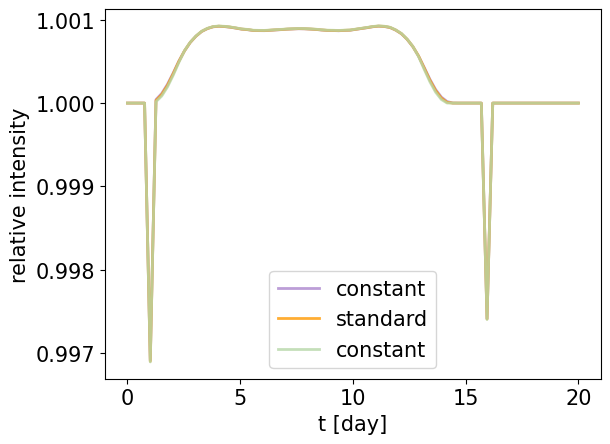

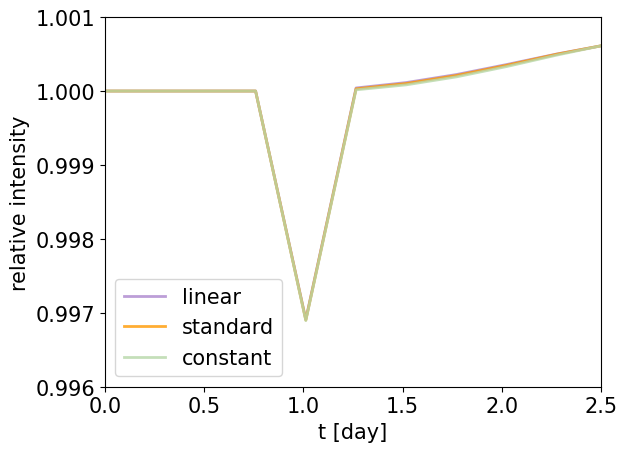

In [9]:
plt.rcParams['font.size'] = 15
plt.rcParams['lines.linewidth'] = 2

plt.plot(t, ss_lin.results['lc'],color='#ab86cd', label='constant', alpha=0.8) 
plt.plot(t, ss_standard.results['lc'], color='#ff9900', label='standard', alpha=0.8) 
plt.plot(t, ss_const.results['lc'],color='#b6d7a8', label='constant', alpha=0.8) 

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('relative intensity')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/limb_extrapolation/lc_fc_phoenix.png', bbox_inches='tight')

plt.show()

plt.rcParams['font.size'] = 15
plt.rcParams['lines.linewidth'] = 2

plt.plot(t, ss_lin.results['lc'],color='#ab86cd', label='linear', alpha=0.8) 
plt.plot(t, ss_standard.results['lc'], color='#ff9900', label='standard', alpha=0.8) 
plt.plot(t, ss_const.results['lc'],color='#b6d7a8', label='constant', alpha=0.8) 

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('relative intensity')
# plt.xlim(12,15)
plt.xlim(0,2.5)
plt.ylim(0.996,1.001)


plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/limb_extrapolation/lc_fc_phoenix_zoom_in.png', bbox_inches='tight')
plt.show()

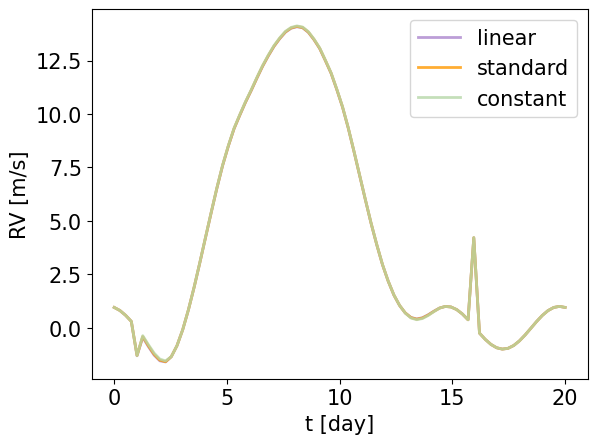

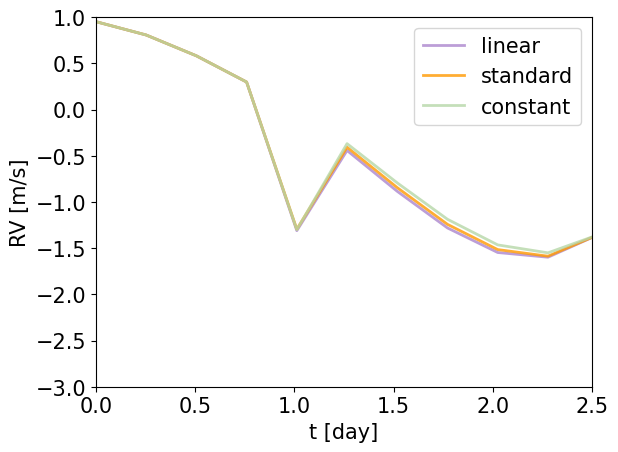

In [10]:
plt.plot(t, ss_lin.results['rv'],color='#ab86cd', label='linear', alpha=0.8) 
plt.plot(t, ss_standard.results['rv'], color='#ff9900', label='standard', alpha=0.8) 
plt.plot(t, ss_const.results['rv'],color='#b6d7a8', label='constant', alpha=0.8) 

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('RV [m/s]')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/limb_extrapolation/rv_fc_phoenix.png', bbox_inches='tight')

plt.show()

plt.plot(t, ss_lin.results['rv'],color='#ab86cd', label='linear', alpha=0.8) 
plt.plot(t, ss_standard.results['rv'], color='#ff9900', label='standard', alpha=0.8) 
plt.plot(t, ss_const.results['rv'],color='#b6d7a8', label='constant', alpha=0.8) 

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('RV [m/s]')
plt.xlim(0,2.5)
plt.ylim(-3,1)

plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/limb_extrapolation/rv_fc_phoenix_zoom_in.png', bbox_inches='tight')

plt.show()

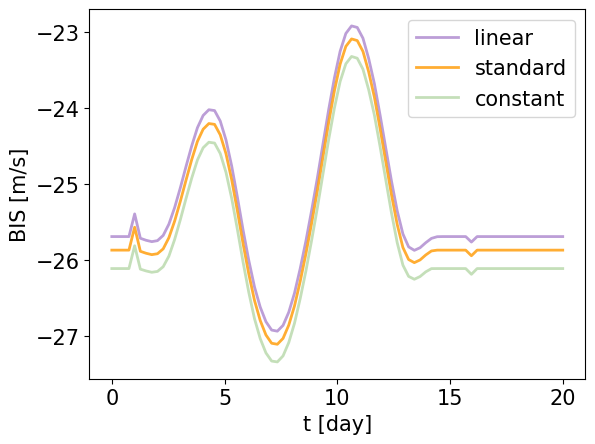

In [11]:
plt.plot(t, ss_lin.results['bis'],color='#ab86cd', label='linear', alpha=0.8) 
plt.plot(t, ss_standard.results['bis'], color='#ff9900', label='standard', alpha=0.8) 
plt.plot(t, ss_const.results['bis'],color='#b6d7a8', label='constant', alpha=0.8) 

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('BIS [m/s]')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/limb_extrapolation/bis_fc_phoenix.png', bbox_inches='tight')

plt.show()

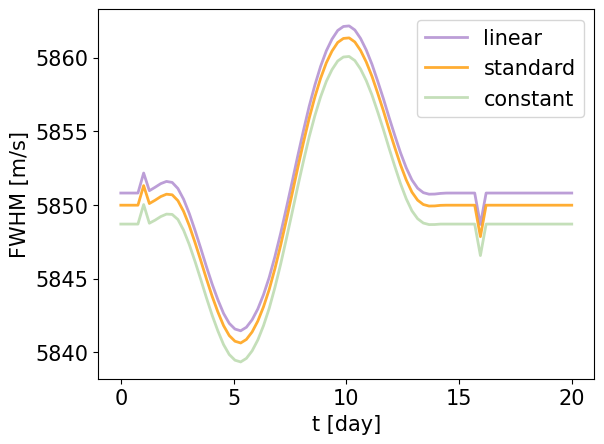

In [12]:
plt.plot(t, ss_lin.results['fwhm'],color='#ab86cd', label='linear', alpha=0.8) 
plt.plot(t, ss_standard.results['fwhm'], color='#ff9900', label='standard', alpha=0.8) 
plt.plot(t, ss_const.results['fwhm'],color='#b6d7a8', label='constant', alpha=0.8) 

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('FWHM [m/s]')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/limb_extrapolation/fwhm_fc_phoenix.png', bbox_inches='tight')

plt.show()

MPS

In [13]:
ss_const = simulation_init(type_list, spot_size_list, latitude_list, longitude_list, conf_file_path)
ss_const.phoenix_spectra = 0
ss_const.limb_lim = 0.1
ss_const.convective_shift = 0
ss_const.compute_forward(observables=['lc', 'rv'],t=t)

ss_lin = simulation_init(type_list, spot_size_list, latitude_list, longitude_list, conf_file_path)
ss_lin.phoenix_spectra = 0
ss_lin.convective_shift = 0
ss_lin.limb_lim = 0.1
ss_lin.limb_extrapolation = 'linear'
ss_lin.compute_forward(observables=['lc', 'rv'],t=t)

MPS-ATLAS spectra
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Date 20.0. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [80/80]%ELSE. [79/80]%
ELSE
ELSE
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: 

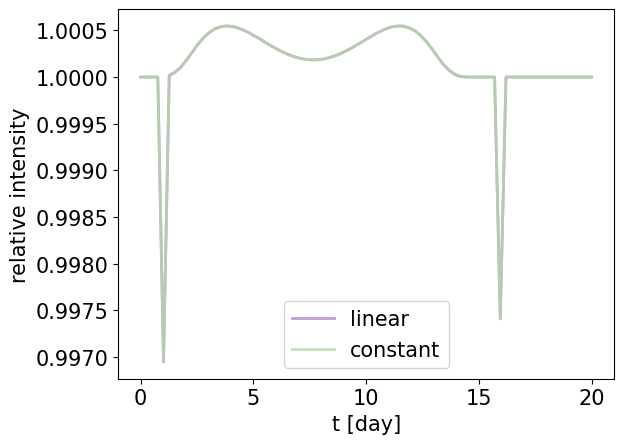

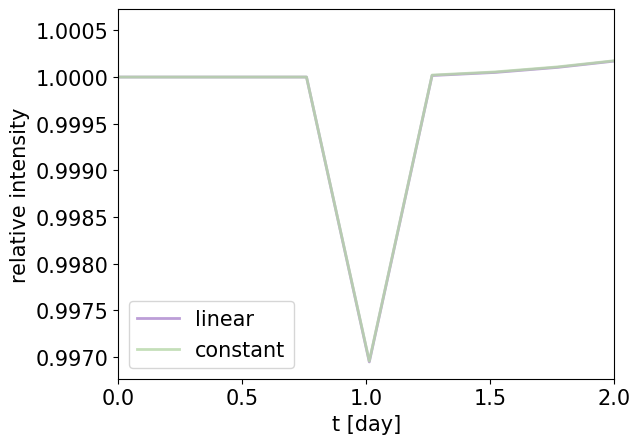

In [14]:
plt.rcParams['font.size'] = 15
plt.rcParams['lines.linewidth'] = 2

plt.plot(t, ss_lin.results['lc'],color='#ab86cd', label='linear', alpha=0.8) 
plt.plot(t, ss_const.results['lc'],color='#b6d7a8', label='constant', alpha=0.8) 

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('relative intensity')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/limb_extrapolation/lc_fc_mps.png', bbox_inches='tight')

plt.show()

plt.rcParams['font.size'] = 15
plt.rcParams['lines.linewidth'] = 2

plt.plot(t, ss_lin.results['lc'],color='#ab86cd', label='linear', alpha=0.8) 
plt.plot(t, ss_const.results['lc'],color='#b6d7a8', label='constant', alpha=0.8) 

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('relative intensity')
# plt.xlim(12,15)
plt.xlim(0,2)

plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/limb_extrapolation/lc_fc_mps_zoom_in.png', bbox_inches='tight')

plt.show()

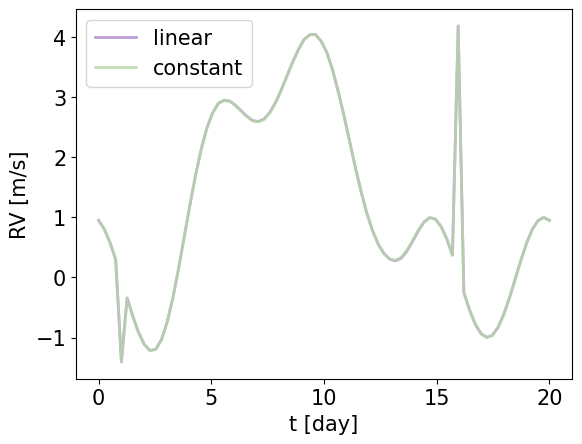

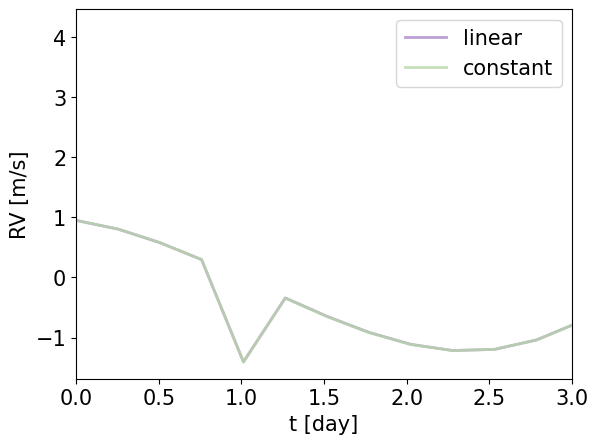

In [15]:
plt.plot(t, ss_lin.results['rv'],color='#ab86cd', label='linear', alpha=0.8) 
plt.plot(t, ss_const.results['rv'],color='#b6d7a8', label='constant', alpha=0.8) 

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('RV [m/s]')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/limb_extrapolation/rv_fc_mps.png', bbox_inches='tight')
plt.show()

plt.plot(t, ss_lin.results['rv'],color='#ab86cd', label='linear', alpha=0.8) 
plt.plot(t, ss_const.results['rv'],color='#b6d7a8', label='constant', alpha=0.8) 

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('RV [m/s]')
# plt.xlim(1,4)
plt.xlim(0,3)

# plt.ylim(-0.5,1)
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/limb_extrapolation/rv_fc_mps_zoom_in.png', bbox_inches='tight')

plt.show()

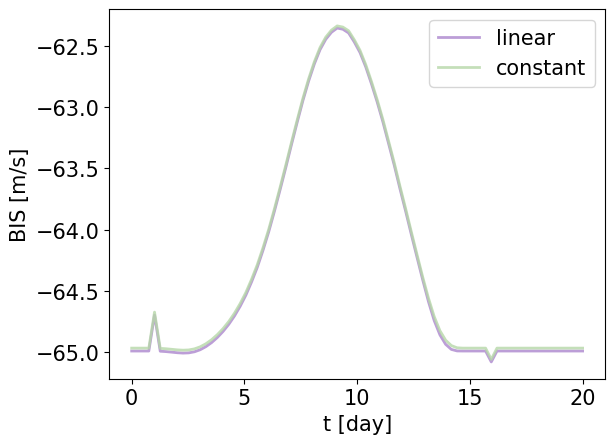

In [16]:
plt.plot(t, ss_lin.results['bis'],color='#ab86cd', label='linear', alpha=0.8) 
plt.plot(t, ss_const.results['bis'],color='#b6d7a8', label='constant', alpha=0.8) 

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('BIS [m/s]')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/limb_extrapolation/bis_fc_mps.png', bbox_inches='tight')

plt.show()

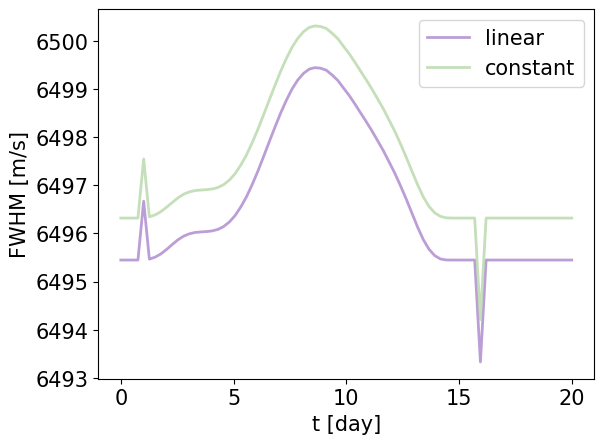

In [17]:
plt.plot(t, ss_lin.results['fwhm'],color='#ab86cd', label='linear', alpha=0.8) 
plt.plot(t, ss_const.results['fwhm'],color='#b6d7a8', label='constant', alpha=0.8) 

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('FWHM [m/s]')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/limb_extrapolation/fwhm_fc_mps.png', bbox_inches='tight')

plt.show()

In [18]:
type_list = [0]

t=np.linspace(0,period *periods_nbr,int(period *periods_nbr*point_nbr))

In [19]:
ss_standard = simulation_init(type_list, spot_size_list, latitude_list, longitude_list, conf_file_path)
ss_standard.compute_forward(observables=['lc', 'rv'],t=t)

ss_const = simulation_init(type_list, spot_size_list, latitude_list, longitude_list, conf_file_path)
ss_const.limb_lim = 0.1
ss_const.compute_forward(observables=['lc', 'rv'],t=t)

ss_lin = simulation_init(type_list, spot_size_list, latitude_list, longitude_list, conf_file_path)
ss_lin.limb_lim = 0.1
ss_lin.limb_extrapolation = 'linear'
ss_lin.compute_forward(observables=['lc', 'rv'],t=t)

PHOENIX spectra
Date 20.0. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [80/80]%000%. [79/80]%RV shift
Date 20.0. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [80/80]%PHOENIX spectra
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Date 20.0. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [80/80]%RV shift9/80]%
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Limb extrapolation: constant for mu <  0.1
Date 20.0. 

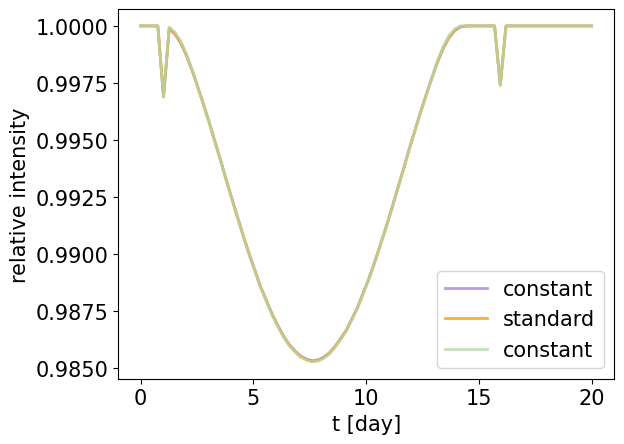

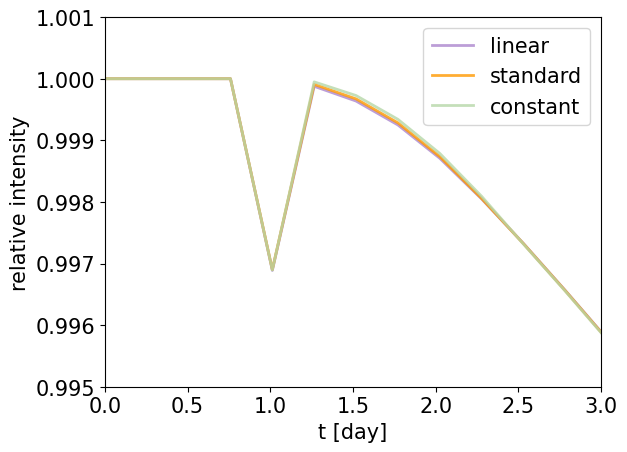

In [20]:
plt.rcParams['font.size'] = 15
plt.rcParams['lines.linewidth'] = 2

plt.plot(t, ss_lin.results['lc'],color='#ab86cd', label='constant', alpha=0.8) 
plt.plot(t, ss_standard.results['lc'], color='#ff9900', label='standard', alpha=0.8) 
plt.plot(t, ss_const.results['lc'],color='#b6d7a8', label='constant', alpha=0.8) 

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('relative intensity')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/limb_extrapolation/lc_sp_phoenix.png', bbox_inches='tight')

plt.show()

plt.rcParams['font.size'] = 15
plt.rcParams['lines.linewidth'] = 2

plt.plot(t, ss_lin.results['lc'],color='#ab86cd', label='linear', alpha=0.8) 
plt.plot(t, ss_standard.results['lc'], color='#ff9900', label='standard', alpha=0.8) 
plt.plot(t, ss_const.results['lc'],color='#b6d7a8', label='constant', alpha=0.8) 

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('relative intensity')
# plt.xlim(12,15)
# plt.ylim(0.994,1.001)


plt.xlim(0,3)
plt.ylim(0.995,1.001)

plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/limb_extrapolation/lc_sp_phoenix_zoom_in.png', bbox_inches='tight')

plt.show()

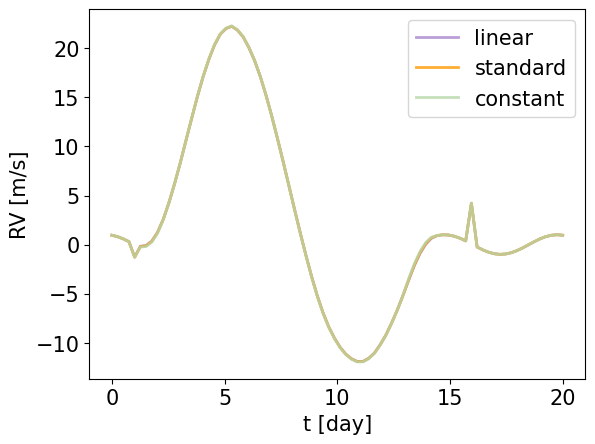

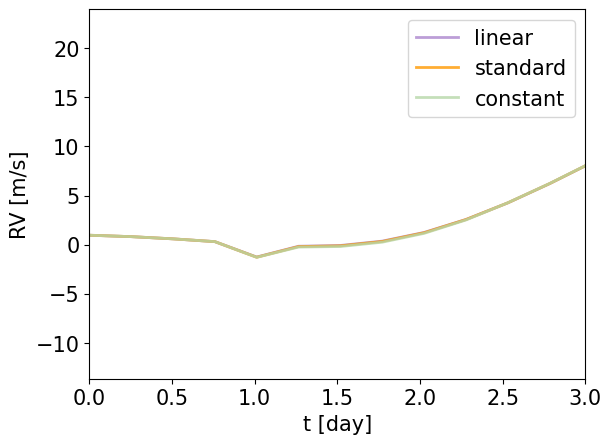

In [21]:
plt.plot(t, ss_lin.results['rv'],color='#ab86cd', label='linear', alpha=0.8) 
plt.plot(t, ss_standard.results['rv'], color='#ff9900', label='standard', alpha=0.8) 
plt.plot(t, ss_const.results['rv'],color='#b6d7a8', label='constant', alpha=0.8) 

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('RV [m/s]')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/limb_extrapolation/rv_sp_phoenix.png', bbox_inches='tight')

plt.show()

plt.plot(t, ss_lin.results['rv'],color='#ab86cd', label='linear', alpha=0.8) 
plt.plot(t, ss_standard.results['rv'], color='#ff9900', label='standard', alpha=0.8) 
plt.plot(t, ss_const.results['rv'],color='#b6d7a8', label='constant', alpha=0.8) 

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('RV [m/s]')
# plt.xlim(12,15)
# plt.ylim(-10,1)
plt.xlim(0,3)
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/limb_extrapolation/rv_sp_phoenix_zoom_in.png', bbox_inches='tight')

plt.show()

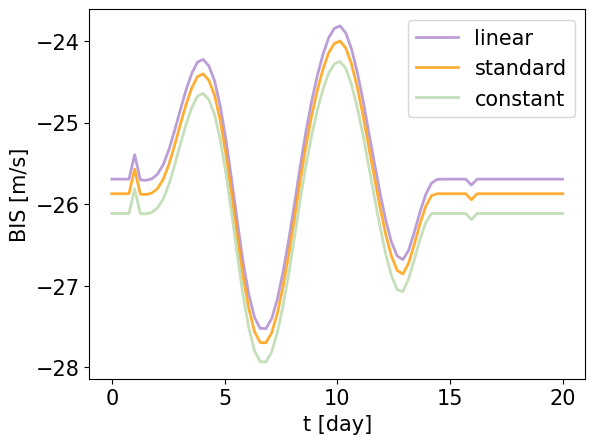

In [22]:
plt.plot(t, ss_lin.results['bis'],color='#ab86cd', label='linear', alpha=0.8) 
plt.plot(t, ss_standard.results['bis'], color='#ff9900', label='standard', alpha=0.8) 
plt.plot(t, ss_const.results['bis'],color='#b6d7a8', label='constant', alpha=0.8) 

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('BIS [m/s]')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/limb_extrapolation/bis_sp_phoenix.png', bbox_inches='tight')

plt.show()

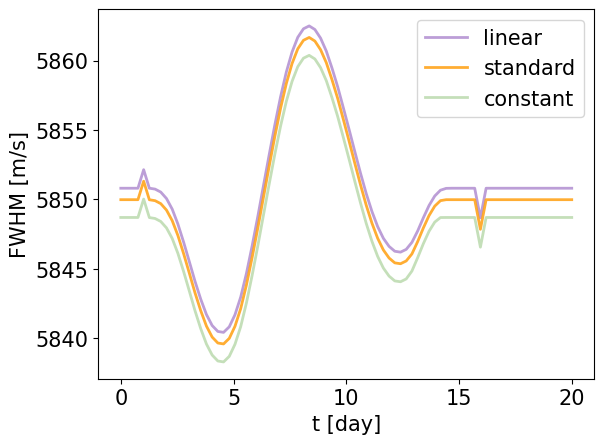

In [23]:
plt.plot(t, ss_lin.results['fwhm'],color='#ab86cd', label='linear', alpha=0.8) 
plt.plot(t, ss_standard.results['fwhm'], color='#ff9900', label='standard', alpha=0.8) 
plt.plot(t, ss_const.results['fwhm'],color='#b6d7a8', label='constant', alpha=0.8) 

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('FWHM [m/s]')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/limb_extrapolation/fwhm_sp_phoenix.png', bbox_inches='tight')

plt.show()